In [2]:
# Cell 1 — Discover SMMR yearly files (advance_YYYY / retreat_YYYY inside each)

import os, re, glob
import xarray as xr
import numpy as np

# ---- EDIT: folder containing SMMR NetCDFs ----
DATA_DIR = "/Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/"
GLOB_PAT = os.path.join(DATA_DIR, "*.nc")
# ----------------------------------------------

# SMMR mission years (adjust if your set is different)
YEARS = list(range(1979, 2025))  # 1979–1988 inclusive

# Find all candidate files
all_files = sorted(glob.glob(GLOB_PAT))

# Map each year -> file path by regexing a 4-digit year in filename
year_re = re.compile(r"(19|20)\d{2}")
year_to_path = {}
for f in all_files:
    m = year_re.search(os.path.basename(f))
    if not m:
        continue
    y = int(m.group(0))
    if y in YEARS and y not in year_to_path:
        year_to_path[y] = f  # first match wins; change if you prefer last

print("Discovered files for years:")
for y in YEARS:
    print(f"  {y}: {year_to_path.get(y, 'MISSING')}")

# Quick peek at variable names in the first available file
def list_phase_vars(nc_path):
    with xr.open_dataset(nc_path) as ds:
        return list(ds.data_vars)

first_path = next((year_to_path[y] for y in YEARS if y in year_to_path), None)
if first_path:
    print("\nExample variables in:", os.path.basename(first_path))
    print(list_phase_vars(first_path))
else:
    print("\nNo matching files found. Check DATA_DIR / pattern / YEARS.")


Discovered files for years:
  1979: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1979.nc
  1980: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1980.nc
  1981: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1981.nc
  1982: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1982.nc
  1983: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1983.nc
  1984: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1984.nc
  1985: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1985.nc
  1986: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1986.nc
  1987: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1987.nc
  1988: /Users/fridaperez/Developer/repos/sea-ice-phas

In [3]:
# Cell 2 — Load advance/retreat across 1979–2023 into ('time','y','x')

YEARS = list(range(1979, 2024)) 

adv_list = []
ret_list = []

for y in YEARS:
    path = year_to_path.get(y)
    if path is None:
        print(f"Skipping {y} (no file found)")
        continue

    with xr.open_dataset(path) as ds:
        adv_var = f"advance_{y}"
        ret_var = f"retreat_{y}"
        if adv_var not in ds or ret_var not in ds:
            print(f"Warning: {os.path.basename(path)} missing {adv_var} or {ret_var}")
            continue

        # Ensure the same (y,x) layout and attach a time coord = year
        adv_list.append(ds[adv_var].expand_dims(time=[y]))
        ret_list.append(ds[ret_var].expand_dims(time=[y]))

# Concatenate along 'time'
adv_all = xr.concat(adv_list, dim="time")
ret_all = xr.concat(ret_list, dim="time")

print("Advance stacked:", adv_all.dims, adv_all.shape)
print("Retreat stacked:", ret_all.dims, ret_all.shape)
print("Years loaded:", adv_all.time.values)


Advance stacked: ('time', 'y', 'x') (45, 332, 316)
Retreat stacked: ('time', 'y', 'x') (45, 332, 316)
Years loaded: [1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992
 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006
 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020
 2021 2022 2023]


In [4]:
# Cell 3 — Circular mean climatologies for advance & retreat

P = 365
TAU = 2*np.pi

def doy_to_angle(doy):
    """Map DOY -> angle [0,2π). Works with xarray DataArray."""
    return (TAU / P) * (doy % P)

# Angles for each year
Aθ = doy_to_angle(adv_all)
Rθ = doy_to_angle(ret_all)

# Compute circular means along time
mean_cos_A = np.cos(Aθ).mean("time")
mean_sin_A = np.sin(Aθ).mean("time")
mean_cos_R = np.cos(Rθ).mean("time")
mean_sin_R = np.sin(Rθ).mean("time")

# Encode back to cos/sin of mean angle
feat = xr.concat([mean_cos_A, mean_sin_A, mean_cos_R, mean_sin_R], dim="feat")
feat = feat.transpose("y","x","feat")
feat = feat.assign_coords(feat=["cosμA","sinμA","cosμR","sinμR"])

print("Feature grid shape:", feat.shape)
print("Features:", list(feat.feat.values))


Feature grid shape: (332, 316, 4)
Features: [np.str_('cosμA'), np.str_('sinμA'), np.str_('cosμR'), np.str_('sinμR')]


In [5]:
# Cell 4 — Flatten features into (N,4) feature matrix for GMM

vals = feat.values               # (Y, X, 4)
Y, Xn, F = vals.shape
assert F == 4, f"Expected 4 features, got {F}"

# Flatten the (y,x) grid into rows
flat = vals.reshape(Y*Xn, F)     # (Y*X, 4)

# Mask: only rows where all 4 features are finite
valid_rows = np.isfinite(flat).all(axis=1)

# Keep only valid rows
X = flat[valid_rows]             # (N, 4)

# Save mask for mapping back
mask_np = valid_rows.reshape(Y, Xn)

def grid_from_vector(vec, mask_boolean):
    out = np.full(mask_boolean.shape, np.nan, dtype=float)
    out[mask_boolean] = vec
    return out

print("X shape (N,4):", X.shape)
print("First 3 rows of X:\n", X[:3])
print("Valid pixel fraction:", mask_np.mean())


X shape (N,4): (40815, 4)
First 3 rows of X:
 [[-0.31719129 -0.94836158 -0.71585096 -0.69820218]
 [-0.33346878 -0.94276114 -0.71585096 -0.69820218]
 [-0.33346878 -0.94276114 -0.71585096 -0.69820218]]
Valid pixel fraction: 0.38904033856946774


In [6]:
# Cell 5 — Fit GMM and select K with BIC

from sklearn.mixture import GaussianMixture

Ks = range(2, 7)
bics = []
best_model = None
best_bic = np.inf

for K in Ks:
    gmm = GaussianMixture(
        n_components=K,
        covariance_type="full",
        n_init=5,
        random_state=42
    )
    gmm.fit(X)
    bic = gmm.bic(X)
    bics.append(bic)
    
    if bic < best_bic:
        best_bic = bic
        best_model = gmm

print("Tested Ks:", list(Ks))
print("BICs:", bics)
print("Best K:", best_model.n_components)

# Cluster results
labels = best_model.predict(X)
probs  = best_model.predict_proba(X)
uncert = 1 - probs.max(axis=1)  # uncertainty per pixel

# Map back to (y,x)
labels_grid = grid_from_vector(labels, mask_np)
uncert_grid = grid_from_vector(uncert, mask_np)

print("labels_grid shape:", labels_grid.shape)
print("uncert_grid shape:", uncert_grid.shape)


Tested Ks: [2, 3, 4, 5, 6]
BICs: [np.float64(-12104.201147926815), np.float64(-83801.82084853717), np.float64(-123377.93802612617), np.float64(-148357.52378455468), np.float64(-161405.676295397)]
Best K: 6
labels_grid shape: (332, 316)
uncert_grid shape: (332, 316)


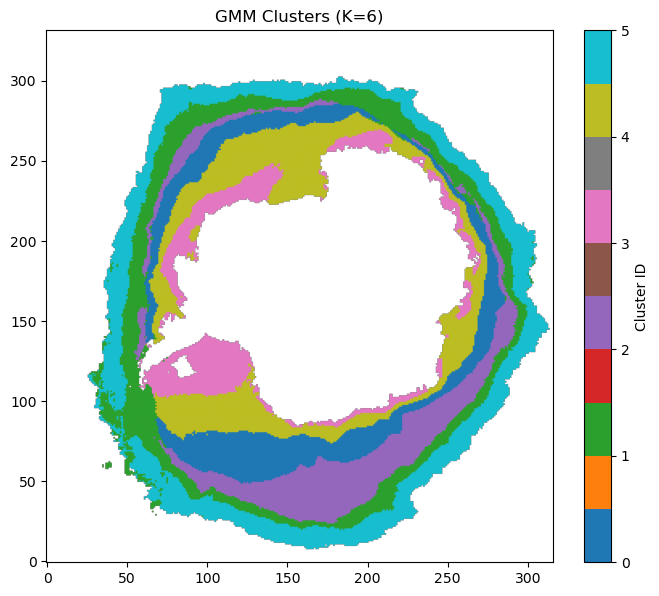

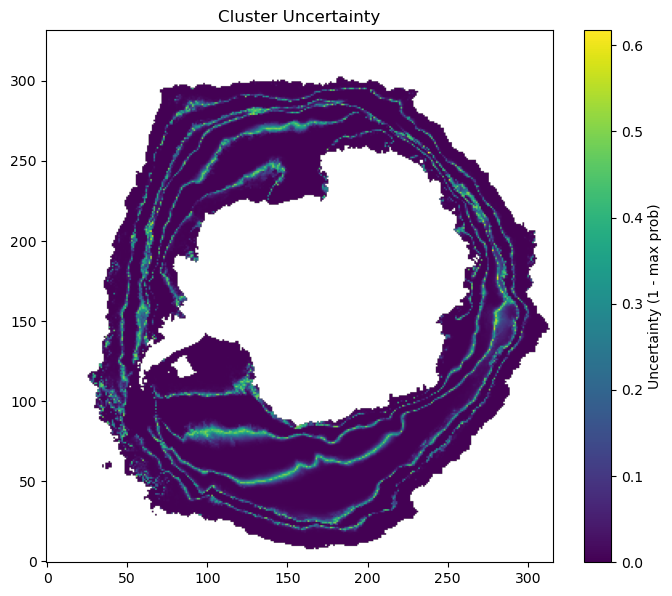

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
im = plt.imshow(labels_grid, origin="lower", cmap="tab10")
plt.title("GMM Clusters (K=6)")
plt.colorbar(im, label="Cluster ID")
plt.tight_layout()

plt.figure(figsize=(7,6))
im2 = plt.imshow(uncert_grid, origin="lower", cmap="viridis")
plt.title("Cluster Uncertainty")
plt.colorbar(im2, label="Uncertainty (1 - max prob)")
plt.tight_layout()
